In [1]:
from graphviz import Digraph
import math
import random

In [2]:
class Value:
    def __init__(self,data,_child=(),_op="",label=""):
        self.data = data
        self._child = set(_child)
        self._op = _op
        self.label = label
        self._backward = lambda:None
        self.grad = 0.0
    def __repr__(self):
        out = f"{self.label} : {self.data}"
        return out
    def __add__(self,other):
        if not isinstance(other,Value): other = Value(other)
        out = Value(self.data+other.data,(self,other),"+")
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out
    def __radd__(self,other):
        out = self + other
        return out
    def __mul__(self,other):
        if not isinstance(other,Value): other = Value(other)
        out = Value(self.data*other.data,(self,other),"*")
        def backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = backward
        return out
    def __rmul__(self,other):
        out = self*other
        return out
    def __neg__(self):
        out = self * -1
        return out
    def __sub__(self,other):
        out = self + (-other)
        return out
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        t = self.data ** other
        out = Value(t,(self, ),f"{self.label}^{other}")
        def backward():
            self.grad += other*(self.data**(other-1))*out.grad
        out._backward= backward
        return out
    def __truediv__(self,other):
        out = self * (other**-1)
        return out
    def exp(self):
        t = math.exp(self.data)
        out = Value(t,(self,),"exp()")
        def backward():
            self.grad += t*out.grad
        out._backward = backward
        return out
    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t,(self,),'tanh()')
        def backward():
          self.grad += (1-t**2)*out.grad
        out._backward = backward
        return out
    def visualise(self):
        node = set() ; edge  = set()
        def visualise_sub(obj):
          if obj not in node:
            node.add(obj)
            for child in obj._child:
              edge.add((child, obj))
              visualise_sub(child)
        visualise_sub(self)
        dot = Digraph(format = 'svg' , graph_attr = {'rankdir':'LR'})
        for n in node:
              dot.node(str(id(n)),f"{n.label} | {n.data:0.4f} | {n.grad:0.4f}", shape = "box")
              if n._op != "":
                dot.node(str(id(n)) + n._op , n._op, shape = "circle" )
                dot.edge(str(id(n)) + n._op , str(id(n)))
        for n1, n2 in edge:
              dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        return dot
    def backward(self):
        topo = []
        visited = set()
        def topo_sort(obj):
             if obj not in visited:
                visited.add(obj)
                for child in obj._child:
                    topo_sort(child)
                topo.append(obj)
             return topo
        topo = topo_sort(self)
        self.grad = 1
        for i in reversed(topo):
            i._backward()

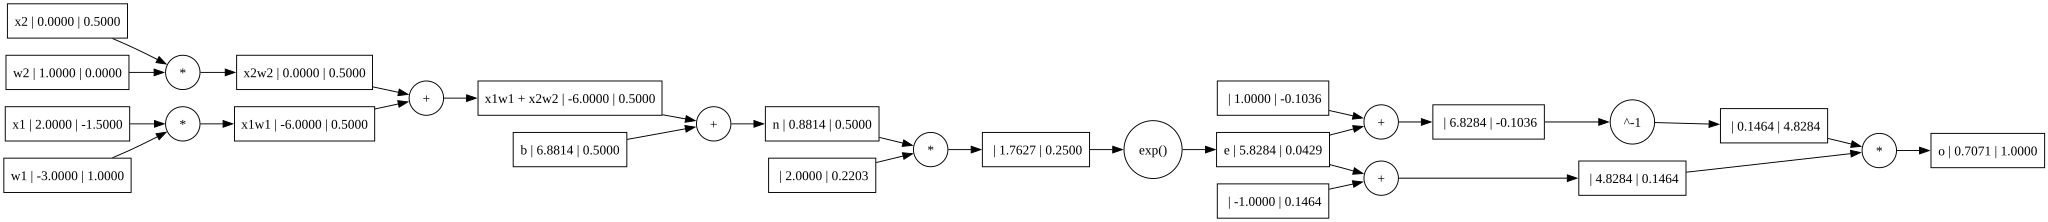

In [3]:
x1 = Value(2.00) ; x1.label= "x1"
w1 = Value(-3.00) ; w1.label= "w1"
x2 = Value(0.00) ; x2.label= "x2"
w2 = Value(1.00) ; w2.label= "w2"
x1w1 = x1*w1 ; x1w1.label= "x1w1"
x2w2 = x2*w2 ; x2w2.label= "x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label= "x1w1 + x2w2"
b = Value(6.88137) ; b.label= "b"
n = x1w1x2w2 + b ; n.label = "n"
e = (2*n).exp() ; e.label= "e"
o = (e-1)/(e+1); o.label = "o"

o.backward()
o.visualise()

In [4]:
class Neuron:
  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
    self.parameters = self.w+[self.b]
  def __call__(self,x):
    t = sum((wi*xi for wi,xi in (zip(self.w,x))),self.b)
    out = t.tanh()
    return out
class Layer:
  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
    self.parameters = [item for neuron in self.neurons for item in neuron.parameters]
  def __call__(self,x):
    out = [n(x) for n in self.neurons]
    return out[0] if len(out) == 1 else out
class MLP:
  def __init__(self,nin,nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    self.parameters = [item for layer in self.layers for item in layer.parameters]
  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

In [5]:
n  = MLP(3,[4,4,1])

In [10]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0,-1.0,-1.0,1.0] # Training to achieve this values

In [11]:
for _ in range(1000):
  # forward
  y_predicted = [n(x) for x in xs]
  loss = sum((y2-y1)**2 for y1,y2 in (zip(ys,y_predicted)))
  # clearing &
  for i in n.parameters:
    i.grad = 0
  if loss.data == 0.000001:
    exit
  # backward
  loss.backward()
  # correction
  for par in n.parameters:
    par.data -= 0.1*par.grad
  if _%100 ==0:
    print(f"loss : {loss.data}")

loss : 2.762087974389326
loss : 0.0025947202726960225
loss : 0.0012434700969628332
loss : 0.0008117164666735547
loss : 0.0006006757827274887
loss : 0.00047594777032598063
loss : 0.0003937147428858402
loss : 0.00033548483559803753
loss : 0.0002921197642617503
loss : 0.00025859007997992384


In [14]:
y_new = [n(x) for x in xs]
print(y_new)

[ : 0.9927695208107983,  : -0.9942583792306692,  : -0.9918095622751483,  : 0.9910796771955819]
